Bin: SmallBin-0
  Dimensions (W×H×D): 30 × 30 × 30
  Max weight: 10
--------------------------------------------------
Bin: MediumBin-0
  Dimensions (W×H×D): 40 × 40 × 30
  Max weight: 10
--------------------------------------------------
Bin: MediumBin-1
  Dimensions (W×H×D): 40 × 40 × 30
  Max weight: 10
--------------------------------------------------
Item: Item-0
  Size (WxHxD): 18 × 23 × 9
  Weight: 0
--------------------------------------------------
Item: Item-1
  Size (WxHxD): 17 × 21 × 9
  Weight: 0
--------------------------------------------------
Item: Item-2
  Size (WxHxD): 15 × 22 × 9
  Weight: 0
--------------------------------------------------
Item: Item-3
  Size (WxHxD): 15 × 23 × 15
  Weight: 0
--------------------------------------------------
Item: Item-4
  Size (WxHxD): 21 × 24 × 11
  Weight: 0
--------------------------------------------------
Item: Item-5
  Size (WxHxD): 20 × 23 × 6
  Weight: 0
--------------------------------------------------
Item: Item-6
  

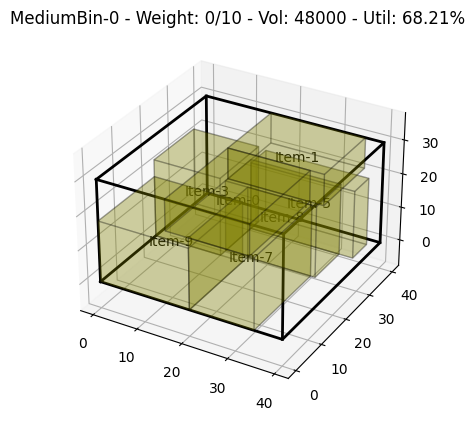

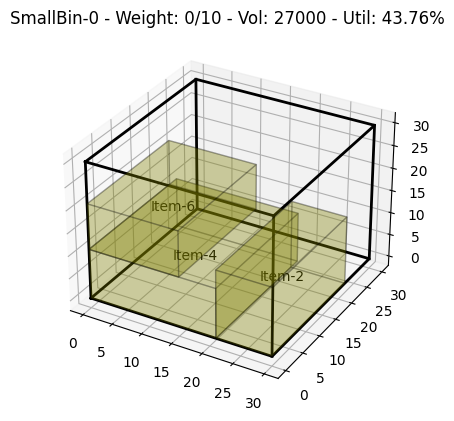

used time :  0.7598834037780762
[[18 23  9]
 [17 21  9]
 [15 22  9]
 [15 23 15]
 [21 24 11]
 [20 23  6]
 [15 22 10]
 [21 22 14]
 [21 20 10]
 [20 20 18]]
[[40 40 30]
 [30 30 30]]


In [66]:
import numpy as np
from py3dbp import Packer, Bin, Item, Painter
import time
import torch
import os

start = time.time()

# Generator of random bins
def generate_random_bins(num_small, num_medium, num_large):
    bins = []

    def create_bin(size_category, index):
        if size_category=="small":
            dims=[30, 30, 30] #np.random.randint(40,51,size=3)
            weight_limit=3000
        elif size_category=="medium":
            dims=[40, 40, 30] #np.random.randint(51,76,size=3)
            weight_limit=5000
        elif size_category=="large":
            dims=[50, 50, 40] #np.random.randint(76,101,size=3)#[100, 100, 100]
            weight_limit=8000
        else:
            raise ValueError("Invalid size category")

        return Bin(
            partno=f'{size_category.capitalize()}Bin-{index}',
            WHD=tuple(int(d) for d in dims),
            max_weight=10,
            #max_weight=weight_limit,
            corner=0,
            put_type=2  # 1: general, 2: open top
        )

    for i in range(num_small):
        bins.append(create_bin("small", i))
    for i in range(num_medium):
        bins.append(create_bin("medium", i))
    for i in range(num_large):
        bins.append(create_bin("large", i))

    return bins
# Generator of random items
def generate_random_items(num_items):
    items=[]
    for i in range(num_items):
        width = np.random.randint(15,30)
        height = np.random.randint(20,30)
        depth = np.random.randint(5,20)
        size = [width, height, depth]
        size=[int(s) for s in size]
        weight=0 #int(np.random.randint(200,500))
        item=Item(
            partno=f'Item-{i}',
            name=f'item {i}',
            typeof='cube',
            WHD=tuple(size),
            weight=weight,
            level=1, # all items have the same packing priority
            loadbear=100,#*sum(size), # all items have the same laod bearing priority
            updown=True, # all items can be placed upside down
            color='olive')
        items.append(item)
    return items

predictions_path = "/home/bakirkhon/Thesis/outputs/2025-10-14/06-44-43-graph-tf-model/predictions/inference_predictions.pt"
assert os.path.exists(predictions_path), f"Missing file: {predictions_path}"
predictions = torch.load(predictions_path)
order_id = 3
# Extract X and E
X = predictions[order_id]["X"]
X = X[:10]

def generate_items(X, selected_indices=None):
    """
    Creates a list of items (or a subset) from a predefined list of [width, height, depth].
    Args:
        selected_indices (list[int], optional): indices of items to extract. If None, all items are created.
    """


    # if no selection provided → all items
    if selected_indices is None:
        selected_indices = range(len(X))

    items = []
    for i in selected_indices:
        width, height, depth = map(int, X[i])
        item = Item(
            partno=f'Item-{i}',
            name=f'item {i}',
            typeof='cube',
            WHD=(width, height, depth),
            weight=0,
            level=1,
            loadbear=100,
            updown=True,
            color='olive'
        )
        items.append(item)

    return items

packer=Packer()

num_small=1 #int(np.random.randint(1,4))
num_medium=2 #int(np.random.randint(1,4))
num_large=0 #int(np.random.randint(1,3)) 
bins=generate_random_bins(num_small, num_medium, num_large)
#num_items=int(np.random.randint(10,20))

#items=generate_random_items(num_items)
items=generate_items(X=X)

num_items=len(items)
for b in bins:
    print(f"Bin: {b.partno}")
    print(f"  Dimensions (W×H×D): {b.width} × {b.height} × {b.depth}")
    print(f"  Max weight: {b.max_weight}")
    print("--------------------------------------------------")
for item in items:
    print(f"Item: {item.partno}")
    print(f"  Size (WxHxD): {item.width} × {item.height} × {item.depth}")
    print(f"  Weight: {item.weight}")
    print("--------------------------------------------------")
for b in bins:
    packer.addBin(b)
for item in items:
    packer.addItem(item)

packer.pack(
    bigger_first=True, # pack into bigger boxes first
    distribute_items=True,
    fix_point=True,
    check_stable=False,
    support_surface_ratio=0.5,
    number_of_decimals=0
)

packer.putOrder()

b=packer.bins[1]
volume = b.width * b.height * b.depth
volume_t = 0
for item in b.items:
    volume_t += float(item.width) * float(item.height) * float(item.depth)
space_utilization = round(volume_t / float(volume) * 100, 2)

repacked = False
if space_utilization <= 40 and len(packer.bins[2].items) == 0:
    print("entered if")
    num_small=1 #int(np.random.randint(1,4))
    num_medium=1 #int(np.random.randint(1,4))
    bins=generate_random_bins(num_small, num_medium, num_large)
    packer_small = Packer()
    for b in bins:
        packer_small.addBin(b)
    for item in items:
        packer_small.addItem(item)
    packer_small.pack(
    bigger_first=True, # pack into bigger boxes first
    distribute_items=True,
    fix_point=True,
    check_stable=False,
    support_surface_ratio=0.5,
    number_of_decimals=0)

    packer_small.putOrder()
    repacked = True

# Choose which packer to print
target_packer = packer_small if repacked else packer
# print(target_packer==packer_small)
# print result

def print_result(packer):
    print("***************************************************")
    for idx,b in enumerate(packer.bins) :
        print("**", b.string(), "**")
        print("***************************************************")
        print("FITTED ITEMS:")
        print("***************************************************")
        volume = b.width * b.height * b.depth
        volume_t = 0
        volume_f = 0
        unfitted_name = ''
        weight_t=0
        for item in b.items:
            print("partno : ",item.partno)
            print("color : ",item.color)
            print("position : ",item.position)
            print("rotation type : ",item.rotation_type)
            print("W*H*D : ",str(item.width) +' * '+ str(item.height) +' * '+ str(item.depth))
            print("volume : ",float(item.width) * float(item.height) * float(item.depth))
            print("weight : ",float(item.weight))
            volume_t += float(item.width) * float(item.height) * float(item.depth)
            weight_t+=float(item.weight)
            print("***************************************************")
        
        space_utilization = round(volume_t / float(volume) * 100, 2)
        print('space utilization :', space_utilization )
        print('residual volume : ', float(volume) - volume_t )
        print('total weight in bin: ', weight_t)
        print("gravity distribution : ",b.gravity)
        print("***************************************************")
        # draw results
        painter = Painter(b)
        fig = painter.plotBoxAndItems(
        title=f"{b.partno} - Weight: {int(weight_t)}/{int(b.max_weight)} - Vol: {int(volume)} - Util: {space_utilization}%",
            alpha=0.2,
            write_num=True,
            fontsize=10
        )

    print("***************************************************")
    print("UNFITTED ITEMS:")
    for item in packer.unfit_items:
        print("***************************************************")
        print('name : ',item.name)
        print("partno : ",item.partno)
        print("color : ",item.color)
        print("W*H*D : ",str(item.width) +' * '+ str(item.height) +' * '+ str(item.depth))
        print("volume : ",float(item.width) * float(item.height) * float(item.depth))
        print("weight : ",float(item.weight))
        volume_f += float(item.width) * float(item.height) * float(item.depth)
        unfitted_name += '{},'.format(item.partno)
        print("***************************************************")
    print("***************************************************")
    print('unpack item : ',unfitted_name)
    print('unpack item volume : ',volume_f)
    fig.show()

print_result(target_packer)
stop = time.time()
print('used time : ',stop - start)



# Generation of item nodes Va
Va=np.array([[int(item.width), int(item.height), int(item.depth)] for item in items])
print(Va)

# Generation of bin size nodes Vb
unique_bin_dims = set((int(bin.width), int(bin.height), int(bin.depth)) for bin in bins)
Vb=np.array(sorted(list(unique_bin_dims),reverse=True))
print(Vb)

# Matrix V=(Va;Vb)
V=np.vstack([Va,Vb])
# print(V)

# Generation of edge set E
n=Va.shape[0]+Vb.shape[0]
E=np.zeros((n,n,max(num_small,num_medium,num_large)))

# Create map of bin size categories and index of each bin in that category
b_sizes={
    'small': num_small,
    'medium': num_medium,
    'large': num_large}

bin_size_map={'small': [], 'medium': [], 'large':[]}

for i,b in enumerate(bins):
    if b.width+b.height+b.depth<=90:
        bin_size_map['small'].append(i)
    elif b.width+b.height+b.depth>90 and b.width+b.height+b.depth<=110:
        bin_size_map['medium'].append(i)
    elif b.width+b.height+b.depth>110:
        bin_size_map['large'].append(i)

# Mapping from bin dims to index in Vb
bin_size_to_vb_index={tuple(dim):i for i, dim in enumerate(Vb)}

# Fill E
for bin_category, bin_indices in bin_size_map.items():
    for local_idx, bin_global_index in enumerate(bin_indices):
        b=bins[bin_global_index]
        bin_dims=(int(b.width),int(b.height),int(b.depth))
        vb_index=bin_size_to_vb_index[bin_dims]
        bin_index=num_items+vb_index

        for item in b.items:
            item_index=int(item.partno.split('-')[1])
            E[item_index][bin_index][local_idx]=1
            E[bin_index][item_index][local_idx]=1

#print(E)


In [67]:
E = np.zeros((n, n, 3))
E[:, :, 0] = 1   # assume initially all pairs have no edge


for bin_category, bin_indices in bin_size_map.items():
    for local_idx, bin_global_index in enumerate(bin_indices):
        b = bins[bin_global_index]
        bin_dims = (int(b.width), int(b.height), int(b.depth))
        vb_index = bin_size_to_vb_index[bin_dims]
        bin_index = num_items + vb_index

        for item in b.items:
            item_index = int(item.partno.split('-')[1])

            # Clear "no edge" indicator
            E[item_index, bin_index, 0] = 0
            E[bin_index, item_index, 0] = 0

            # Set one-hot for this specific edge type (+1 offset since 0 is no-edge)
            edge_type_channel = local_idx + 1
            E[item_index, bin_index, edge_type_channel] = 1
            E[bin_index, item_index, edge_type_channel] = 1

def format_sublist(subarr):
    # convert a [x y z] array to a string like [x, y, z]
    return "[" + ", ".join(f"{v:g}" for v in subarr) + "]"

def format_matrix(m):
    # convert a 3D mtx into nested list string format with commas
    lines = []
    for row in m:
        row_str = ", ".join(format_sublist(sub) for sub in row)
        lines.append(f"[{row_str}],")
    return "\n".join(lines)

print(format_matrix(E))

[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0], [1, 0, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [0, 1, 0]],
[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0,

Loaded 800 predicted graphs for inference.
Loaded order 3 with X shape torch.Size([10, 3]) and E shape (1, 12, 12, 3)

Bin node 10:
  Bin 1: [2, 3, 4, 6, 7, 8, 9]
  Bin 2: None

Bin node 11:
  Bin 1: [0, 1, 5]
  Bin 2: None

✅ Final packing_plan dictionary:
{10: {1: [2, 3, 4, 6, 7, 8, 9], 2: []}, 11: {1: [0, 1, 5], 2: []}}

=== Packing for MEDIUM bins (node 10) ===

--- Packing Bin 1 (medium) ---
***************************************************
** MediumBin-0(40x40x30, max_weight:10) vol(48000) **
***************************************************
FITTED ITEMS:
***************************************************
partno :  Item-9
color :  olive
position :  [Decimal('0'), Decimal('0'), Decimal('0')]
rotation type :  0
W*H*D :  20 * 20 * 18
volume :  7200.0
weight :  0.0
***************************************************
partno :  Item-7
color :  olive
position :  [Decimal('20'), Decimal('0'), Decimal('0')]
rotation type :  3
W*H*D :  21 * 22 * 14
volume :  6468.0
weight :  0.0
*****

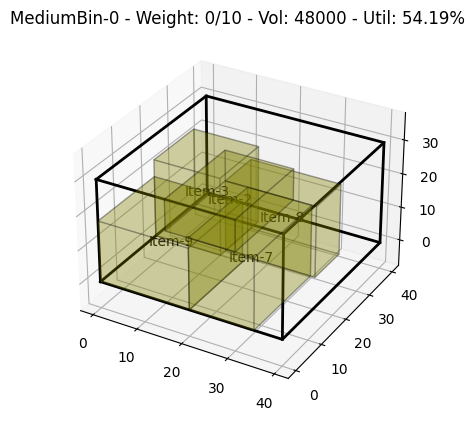


--- Packing Bin 2 (medium) ---
  Bin 2 is empty

=== Packing for SMALL bins (node 11) ===

--- Packing Bin 1 (small) ---
***************************************************
** SmallBin-0(30x30x30, max_weight:10) vol(27000) **
***************************************************
FITTED ITEMS:
***************************************************
partno :  Item-4
color :  olive
position :  [Decimal('0'), Decimal('0'), Decimal('0')]
rotation type :  0
W*H*D :  21 * 24 * 11
volume :  5544.0
weight :  0.0
***************************************************
partno :  Item-0
color :  olive
position :  [Decimal('21'), Decimal('0'), Decimal('0')]
rotation type :  3
W*H*D :  18 * 23 * 9
volume :  3726.0
weight :  0.0
***************************************************
partno :  Item-5
color :  olive
position :  [Decimal('0'), Decimal('24'), Decimal('0')]
rotation type :  2
W*H*D :  20 * 23 * 6
volume :  2760.0
weight :  0.0
***************************************************
partno :  Item-6
color

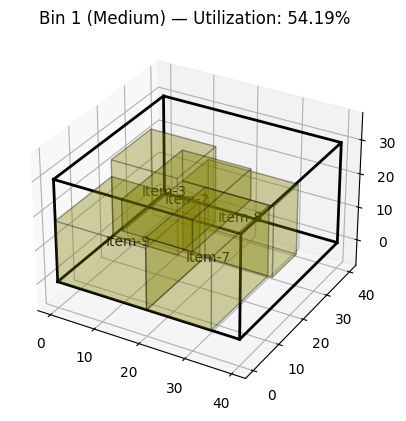

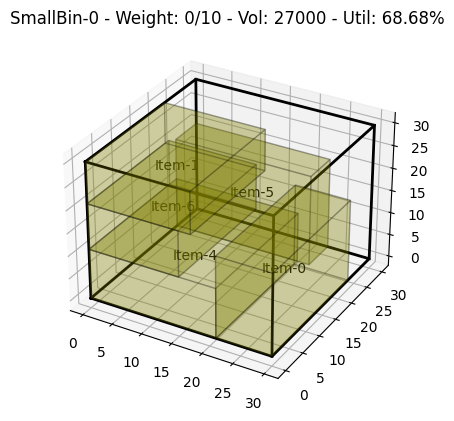


--- Packing Bin 2 (small) ---
  Bin 2 is empty


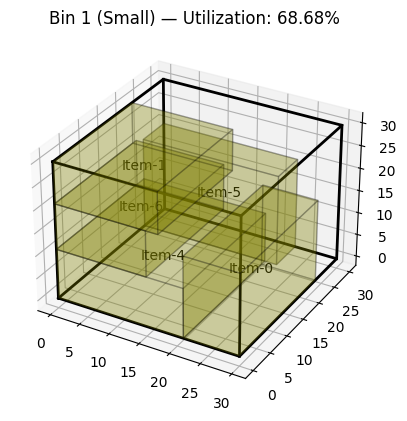

In [68]:
import tkinter as tk
from tkinter import messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import torch
import os

# load inference predictions (your model outputs)
predictions_path = "/home/bakirkhon/Thesis/outputs/2025-10-14/06-44-43-graph-tf-model/predictions/inference_predictions.pt"
assert os.path.exists(predictions_path), f"Missing file: {predictions_path}"
predictions = torch.load(predictions_path)
num_orders = len(predictions)
print(f"Loaded {num_orders} predicted graphs for inference.")


# tkinter setup
root = tk.Tk()
root.title("3D Bin Packing Inference Viewer")
root.geometry("900x700")

# input field
tk.Label(root, text="Enter Order ID (0 - {}):".format(num_orders - 1), font=("Arial", 12)).pack(pady=10)
entry_order = tk.Entry(root, font=("Arial", 12))
entry_order.pack()

canvas_container = tk.Frame(root)
canvas_container.pack(fill="both", expand=True, pady=10)

# horizontal scrollable region
scroll_x = tk.Scrollbar(canvas_container, orient="horizontal")
scroll_x.pack(side="bottom", fill="x")

scroll_canvas = tk.Canvas(canvas_container, xscrollcommand=scroll_x.set)
scroll_x.config(command=scroll_canvas.xview)
scroll_canvas.pack(side="top", fill="both", expand=True)

figure_row = tk.Frame(scroll_canvas)
scroll_canvas.create_window((0, 0), window=figure_row, anchor="nw")

def update_scroll_region(event=None):
    scroll_canvas.configure(scrollregion=scroll_canvas.bbox("all"))

figure_row.bind("<Configure>", update_scroll_region)

def run_packing():
    """Load order by ID, extract X, run packing, show 3D plot."""
    for widget in figure_row.winfo_children():
        widget.destroy()  # only remove old plots


    try:
        order_id = int(entry_order.get())
    except ValueError:
        messagebox.showerror("Error", "Please enter a valid integer order ID.")
        return

    if not (0 <= order_id < num_orders):
        messagebox.showerror("Error", f"Order ID must be between 0 and {num_orders - 1}.")
        return

    # Extract X and E
    X = torch.tensor(predictions[order_id]["X"], dtype=torch.float32)
    X = X[:10]
    E = predictions[order_id]["E"]
    print(f"Loaded order {order_id} with X shape {X.shape} and E shape {E.shape}")
    bs, n, n, de = E.shape

    upper_cols = range(n - 2, n)  # last two columns = bins

    all_packing_plans = []  # store one plan per batch

    for b in range(bs):
        # Create container for each bin node
        bin_items = {col: {etype: [] for etype in range(1, de)} for col in upper_cols}

        for row in range(n - 2):  # loop over item nodes
            for col in upper_cols:  # loop over bin nodes
                edge_vector = E[b, row, col]
                edge_type = np.argmax(edge_vector)

                # Ignore no-edge (index 0)
                if edge_type > 0:
                    bin_items[col][edge_type].append(row)

        # Save to global list
        all_packing_plans.append(bin_items)

        # print summary
        for col in upper_cols:
            print(f"\nBin node {col}:")
            for edge_type, items in bin_items[col].items():
                if items:
                    print(f"  Bin {edge_type}: {items}")
                else:
                    print(f"  Bin {edge_type}: None")

    # Extract single plan if bs == 1
    if len(all_packing_plans) == 1:
        packing_plan = all_packing_plans[0]
        print("\n✅ Final packing_plan dictionary:")
        print(packing_plan)
    

    # Packing logic 
    # Map node indices to bin types
    bin_size_map = {10: "medium", 11: "small"}
    packers = {}
    carry_over_items = []

    for col, bins_dict in packing_plan.items():
        bin_size_label = bin_size_map[col]
        print(f"\n=== Packing for {bin_size_label.upper()} bins (node {col}) ===")

        packers[col] = {}
        for bin_id, item_indices in bins_dict.items():
            print(f"\n--- Packing Bin {bin_id} ({bin_size_label}) ---")
            if bin_size_label == "medium":
                base_bins = generate_random_bins(num_small=0, num_medium=1, num_large=0)
            elif bin_size_label == "small":
                base_bins = generate_random_bins(num_small=1, num_medium=0, num_large=0)

            packer = Packer()
            for b in base_bins:
                packer.addBin(b)

            if len(item_indices) > 0:
                all_items_indices = item_indices + [
                    int(item.partno.split("-")[-1]) for item in carry_over_items if hasattr(item, 'partno')
                ]
            else:
                print(f"  Bin {bin_id} is empty")
                continue

            items = generate_items(X, all_items_indices)
            for item in items:
                packer.addItem(item)

            packer.pack(
                bigger_first=True,
                distribute_items=True,
                fix_point=True,
                check_stable=False,
                support_surface_ratio=0.5,
                number_of_decimals=0
            )

            packer.putOrder()
            print_result(packer)

            # Compute utilization and list items
            b = packer.bins[0]
            volume = b.width * b.height * b.depth
            used_volume = sum(float(it.width) * float(it.height) * float(it.depth) for it in b.items)
            utilization = round(used_volume / float(volume) * 100, 2)

            # Create item list text
            item_list_text = "\n".join([f"* {it.partno} ({int(it.width)}x{int(it.height)}x{int(it.depth)})"
                                        for it in b.items]) or "No items packed."

            # Draw 3D figure
            painter = Painter(b)
            fig = painter.plotBoxAndItems(
                title=f"Bin {bin_id} ({bin_size_label.capitalize()}) — Utilization: {utilization}%",
                alpha=0.2,
                write_num=True,
                fontsize=10
            )

            # Embed figure in Tkinter
            from matplotlib import pyplot as plt
            if not hasattr(fig, 'set_canvas'):
                fig = plt.gcf()

            frame = tk.Frame(figure_row)
            frame.grid(row=0, column=len(figure_row.winfo_children()), padx=10, pady=10)

            # Create left text panel for item list
            text_box = tk.Text(frame, width=25, height=20, wrap="word", font=("Arial", 10))
            text_box.insert("1.0", f"Items in bin:\n\n{item_list_text}")
            text_box.config(state="disabled", bg="#f7f7f7")
            text_box.pack(side="left", fill="y", padx=5, pady=5)

            # Place figure to the right
            canvas = FigureCanvasTkAgg(fig, master=frame)
            canvas.draw()
            canvas.get_tk_widget().pack(side="right", fill="both", expand=True, padx=5, pady=5)

            packers[col][bin_id] = packer
            carry_over_items = packer.unfit_items

    if carry_over_items:
        print(f"\n⚠️ {len(carry_over_items)} unfitted items remain. Trying to pack in SMALL bin...")

        # Create a small bin for remaining items
        small_bins = generate_random_bins(num_small=1, num_medium=0, num_large=0)
        final_packer = Packer()
        for b in small_bins:
            final_packer.addBin(b)

        for item in carry_over_items:
            final_packer.addItem(item)

        # Pack and finalize
        final_packer.pack(bigger_first=False, distribute_items=True, fix_point=True, check_stable=False)
        final_packer.putOrder()
        print_result(final_packer)

        # Compute utilization
        b = final_packer.bins[0]
        volume = b.width * b.height * b.depth
        used_volume = sum(float(it.width) * float(it.height) * float(it.depth) for it in b.items)
        utilization = round(used_volume / float(volume) * 100, 2)

        # Create item list text
        item_list_text = "\n".join([
            f"* {it.partno} ({int(it.width)}x{int(it.height)}x{int(it.depth)})"
            for it in b.items
        ]) or "No items packed."

        # Draw figure
        painter = Painter(b)
        fig = painter.plotBoxAndItems(
            title=f"Final Small Bin — Utilization: {utilization}%",
            alpha=0.2,
            write_num=True,
            fontsize=10
        )

        from matplotlib import pyplot as plt
        if not hasattr(fig, 'set_canvas'):
            fig = plt.gcf()

        # Embed figure in horizontal row
        frame = tk.Frame(figure_row)
        frame.grid(row=0, column=len(figure_row.winfo_children()), padx=10, pady=10)

        # Create left text panel for item list
        text_box = tk.Text(frame, width=25, height=20, wrap="word", font=("Arial", 10))
        text_box.insert("1.0", f"Items in bin:\n\n{item_list_text}")
        text_box.config(state="disabled", bg="#f7f7f7")
        text_box.pack(side="left", fill="y", padx=5, pady=5)

        # Place figure to the right
        canvas = FigureCanvasTkAgg(fig, master=frame)
        canvas.draw()
        canvas.get_tk_widget().pack(side="right", fill="both", expand=True, padx=5, pady=5)

        # Refresh GUI
        root.update_idletasks()
        root.update()

# Run button
tk.Button(root, text="Run Packing", command=run_packing, font=("Arial", 12), bg="#4CAF50", fg="white").pack(pady=10)

root.mainloop()
